In [30]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special
from scipy.special import wofz
from scipy.signal import find_peaks
from scipy.interpolate import interp1d


C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

CIV_nu_K = 1.936410e15
CIV_nu_H = 1.933182e15

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm


cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s


emu_e = 1.602e-19*3e9 # Electric charge : emu
m_e = 9.10938356e-28 # Electron Mass : g 
C_IV_gamma_H = 2.64e+8 
C_IV_gamma_K = 2.65e+8 
C_IV_f12_H   = 0.0952e0
C_IV_f12_K   = 0.190e0


c_cms = 2.99792458e10  # Light Speed : cm/s


NN = int(5e4)
C_IV_N = np.linspace(1e12, 1e17, NN)
nu = np.linspace(1.8e15,2.0e15,10000) # frequency

rr = np.arange(12, 18, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

Del_V = (CIV_nu_K/ nu -1)*cc_k
V_c = 250 # km/s ()
Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k



def nos_tau_less_one(NCIV,Random_motion):
    sigma0_K = (np.sqrt(np.pi)*emu_e**2)  *C_IV_f12_K / (m_e*c_cms) 
    factor_K = sigma0_K * c_cms / CIV_nu_K
    NoS = (2.67e13 / 11.8e5)*factor_K *(NCIV/2.67e13)*(11.8/Random_motion)
    print((2.67e13 / 11.8e5)*factor_K)
    return NoS


def calculate_order_and_value(value):
    """ 주어진 값에 대해 변환된 값과 해당 order 반환 """

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3

#combine K and H lines
def K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/Claude_CIV_data/Data_CIV_Claude/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy()
    spec_sc = data[2].to_numpy()
   # spec_pol_tot = data[3]
   # spec_pol_scat = data[4]
    return lam , spec_tot , spec_sc



#separate K and H line
def K_H_from_Combine_data_x(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/Claude_CIV_data/Data_CIV_Claude/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat , x


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/Claude_CIV_data/Data_CIV_Claude/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran)
    lam_c =  (C_IV_K_A + C_IV_H_A) / 2
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

# lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

import numpy as np
from scipy.interpolate import PchipInterpolator

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_scat = K_H_from_Combine_data(
        Line, atom_num, atom_index, vout, vemit, vran
    )

    if lam[0] > lam[-1]:
        sort_idx = np.argsort(lam)
        lam = lam[sort_idx]
        spec_scat = spec_scat[sort_idx]

    if Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    elif Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    else:
        raise ValueError("Invalid Line input")

    win = 5.0
    mask0 = (lam >= lambda_0 - win) & (lam <= lambda_0 + win)
    lam_use = lam[mask0]
    spec_use = spec_scat[mask0]

    lam_fine = np.linspace(lam_use.min(), lam_use.max(), 50000)
    f = PchipInterpolator(lam_use, spec_use)
    spec_fine = f(lam_fine)

    grad = np.gradient(spec_fine, lam_fine)
    sign = np.sign(grad)

    for i in range(1, len(sign)):
        if sign[i] == 0:
            sign[i] = sign[i - 1]

    peak_idx = np.where((sign[:-1] > 0) & (sign[1:] < 0))[0] + 1
    peak_lambda_all = lam_fine[peak_idx]
    peak_values_all = spec_fine[peak_idx]

    mask = peak_values_all > 10000
    peak_lambda_all2 = peak_lambda_all[mask]
    peak_values_all2 = peak_values_all[mask]

    center_idx = np.argmin(np.abs(lam_fine - lambda_0))
    center_value = spec_fine[center_idx]

    order_all = np.argsort(peak_lambda_all2)
    peak_lambda_all2 = peak_lambda_all2[order_all]
    peak_values_all2 = peak_values_all2[order_all]

    if len(peak_lambda_all2) < 2:
        return 0.0, []

    if center_value >= 0.98 * np.max(peak_values_all2):
        return 0.0, []

    max_diff = -np.inf
    best_i, best_j = 0, 1

    for i in range(len(peak_lambda_all2)):
        for j in range(i + 1, len(peak_lambda_all2)):
            diff = peak_lambda_all2[j] - peak_lambda_all2[i]
            if diff > max_diff:
                max_diff = diff
                best_i, best_j = i, j

    peak_lambda = np.array([peak_lambda_all2[best_i], peak_lambda_all2[best_j]])
    del_v = ((peak_lambda[1] - lambda_0) / lambda_0) * cc_k * 2

    return del_v, peak_lambda
    # return del_v, peak_lambda #, top_2_indices

def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel


def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))


def analytic_solution(Line, v_th):

    b = v_th
    sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

    del_nu_K = (b / cc_k) * CIV_nu_K
    del_nu_H = (b / cc_k) * CIV_nu_H

    x_K = (nu - CIV_nu_K) / del_nu_K
    x_H = (nu - CIV_nu_H) / del_nu_H

    a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
    a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

    K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K) / np.sqrt(np.pi)
    H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H) / np.sqrt(np.pi)

    cross_sec = sigma0 * (K_term + H_term)

    K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
    H_region = np.where((Del_V >= Vsep - V_c) & (Del_V <= Vsep + V_c))

    delV_K, cs_K = Del_V[K_region], cross_sec[K_region]
    delV_H, cs_H = Del_V[H_region], cross_sec[H_region]

    x_kk = delV_K / (-b)
    x_hh = (delV_H - Vsep) / (-b)

    tau_profile_K = C_IV_N[:, None] * cs_K
    tau_profile_H = C_IV_N[:, None] * cs_H

    x_esc = np.zeros(len(C_IV_N))
    FWHM_tau05 = np.zeros(len(C_IV_N))

    def find_tau_crossings(x_arr, tau_arr, level):
        s = tau_arr - level
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_arr[jj], tau_arr[jj + 1]
            x_a, x_b = x_arr[jj], x_arr[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (level - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        return np.array(x_candidates)

    def get_width_with_your_rule(delv_arr, tau_arr):
        peak_ii = np.argmax(tau_arr)
        peak_tau = tau_arr[peak_ii]

        if peak_tau <= 1.0:
            level = 0.5 * peak_tau
        else:
            level = 0.5

        delV_half = find_tau_crossings(delv_arr, tau_arr, level)

        if len(delV_half) >= 2:
            return np.max(delV_half) - np.min(delV_half)

        elif len(delV_half) == 1:
            # 중심 대칭 fallback
            return 2.0 * np.abs(delV_half[0])

        else:
            # crossing이 하나도 없으면 peak 기준 대칭 fallback
            return 2.0 * np.abs(delv_arr[peak_ii]) * 50

    if Line.upper() == 'K':
        for ii in range(len(C_IV_N)):
            tau_i = tau_profile_K[ii, :]

            # tau = 1 crossing
            x_tau1 = find_tau_crossings(x_kk, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc[ii] = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i)
                x_esc[ii] = np.abs(x_kk[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05[ii] = get_width_with_your_rule(delV_K, tau_i)

        del_lam_D = (b * 1e5) / C_IV_K
        nu_0_K = cc / C_IV_K
        real_x_esc = x_esc 
        nu_esc = real_x_esc * del_lam_D + nu_0_K
        V_peak_sep = 2 * abs((nu_esc - nu_0_K) / nu_0_K) * cc / 1e5
        v_esc = x_esc * b
        N_esc = 1 / special.erfc(real_x_esc)

        return delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05

    elif Line.upper() == 'H':
        for ii in range(len(C_IV_N)):
            tau_i = tau_profile_H[ii, :]

            # tau = 1 crossing
            x_tau1 = find_tau_crossings(x_hh, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc[ii] = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i)
                x_esc[ii] = np.abs(x_hh[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05[ii] = get_width_with_your_rule(delV_H, tau_i)

        del_lam_D = (b * 1e5) / C_IV_H
        nu_0_H = cc / C_IV_H
        real_x_esc = x_esc 
        nu_esc = real_x_esc * del_lam_D + nu_0_H
        V_peak_sep = 2 * abs((nu_esc - nu_0_H) / nu_0_H) * cc / 1e5
        v_esc = real_x_esc * b
        N_esc = 1 / special.erfc(real_x_esc)

        return delV_H, cs_H, real_x_esc, V_peak_sep, N_esc, FWHM_tau05



FWHM

In [31]:
import numpy as np
from scipy.interpolate import PchipInterpolator

def FWHM(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)

    eps = 1e-12  # 절대 0 반환 방지용 최소값

    if len(lam) == 0:
        return eps

    if lam[0] > lam[-1]:
        sort_idx = np.argsort(lam)
        lam = lam[sort_idx]
        spec_halo = spec_halo[sort_idx]

    if Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    elif Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    else:
        raise ValueError("Invalid Line input")

    win = 5.0
    mask0 = (lam >= lambda_0 - win) & (lam <= lambda_0 + win)
    lam_use = lam[mask0]
    spec_use = spec_halo[mask0]

    # window 안에 데이터가 없으면 전체 데이터라도 사용
    if len(lam_use) == 0:
        lam_use = lam.copy()
        spec_use = spec_halo.copy()

    # 그래도 점이 0개면 진짜 방법이 없으니 아주 작은 양수 반환
    if len(lam_use) == 0:
        return eps

    # 점이 1개뿐이면 local spacing을 만들 수 없으니 최소 양수 반환
    if len(lam_use) == 1:
        return eps

    # -------------------------------------------------
    # 보간
    # -------------------------------------------------
    try:
        lam_fine = np.linspace(lam_use.min(), lam_use.max(), 50000)
        f = PchipInterpolator(lam_use, spec_use)
        spec_fine = f(lam_fine)
    except Exception:
        # 보간 실패 시 원 데이터 사용
        lam_fine = lam_use.copy()
        spec_fine = spec_use.copy()

    # 안전장치
    if len(lam_fine) < 2:
        return eps

    # -------------------------------------------------
    # 공통 유틸
    # -------------------------------------------------
    def positive(v):
        v = float(abs(v))
        return v if v > 0 else eps

    def width_from_two_lam(x1, x2):
        v1 = lam_to_vel(x1)
        v2 = lam_to_vel(x2)
        return positive(v2 - v1)

    def find_crossings(x, y, level, peak_idx):
        yy = y - level

        left_x = None
        for i in range(peak_idx - 1, -1, -1):
            y1 = yy[i]
            y2 = yy[i + 1]
            if y1 == 0:
                left_x = x[i]
                break
            if y1 * y2 < 0:
                x1 = x[i]
                x2 = x[i + 1]
                left_x = x1 - y1 * (x2 - x1) / (y2 - y1)
                break

        right_x = None
        for i in range(peak_idx, len(x) - 1):
            y1 = yy[i]
            y2 = yy[i + 1]
            if y1 == 0:
                right_x = x[i]
                break
            if y1 * y2 < 0:
                x1 = x[i]
                x2 = x[i + 1]
                right_x = x1 - y1 * (x2 - x1) / (y2 - y1)
                break

        return left_x, right_x

    def gaussian_fwhm_from_logfit(x, y, peak_idx):
        # Gaussian: y = A exp(-(x-mu)^2 / (2 sigma^2))
        # ln y = a x^2 + b x + c, sigma = sqrt(-1/(2a))
        n = len(x)
        i0 = max(0, peak_idx - 8)
        i1 = min(n, peak_idx + 9)

        xx = x[i0:i1]
        yy = y[i0:i1]

        # 양수값만 사용
        mask = yy > 0
        xx = xx[mask]
        yy = yy[mask]

        if len(xx) < 3:
            return None

        try:
            coeff = np.polyfit(xx, np.log(yy), 2)
            a, b, c = coeff
            if a >= 0:
                return None
            sigma = np.sqrt(-1.0 / (2.0 * a))
            fwhm_lam = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma

            # lambda 폭 -> velocity 폭
            mu = -b / (2.0 * a)
            x_left = mu - 0.5 * fwhm_lam
            x_right = mu + 0.5 * fwhm_lam
            return width_from_two_lam(x_left, x_right)
        except Exception:
            return None

    def moment_fwhm(x, y):
        # 마지막 fallback: 양수 가중치 기반 second moment
        yy = np.array(y, dtype=float)
        yy = yy - np.min(yy)
        yy[yy < 0] = 0

        s = np.sum(yy)
        if s <= 0:
            return None

        mu = np.sum(x * yy) / s
        var = np.sum(yy * (x - mu) ** 2) / s
        if var <= 0:
            return None

        sigma = np.sqrt(var)
        fwhm_lam = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma
        x_left = mu - 0.5 * fwhm_lam
        x_right = mu + 0.5 * fwhm_lam
        return width_from_two_lam(x_left, x_right)

    def single_peak_fwhm(x, y, peak_idx):
        peak_val = y[peak_idx]
        if peak_val <= 0:
            # 음수/0 peak면 Gaussian fallback
            g = gaussian_fwhm_from_logfit(x, y, peak_idx)
            if g is not None:
                return positive(g)
            m = moment_fwhm(x, y)
            if m is not None:
                return positive(m)
            return eps

        HM = 0.5 * peak_val
        left_x, right_x = find_crossings(x, y, HM, peak_idx)

        # 정상 케이스: 좌우 둘 다 있으면 그대로
        if (left_x is not None) and (right_x is not None):
            return width_from_two_lam(left_x, right_x)

        # 한쪽만 있으면 대칭 가정
        peak_x = x[peak_idx]
        if (left_x is not None) and (right_x is None):
            dx = peak_x - left_x
            right_x = peak_x + dx
            return width_from_two_lam(left_x, right_x)

        if (left_x is None) and (right_x is not None):
            dx = right_x - peak_x
            left_x = peak_x - dx
            return width_from_two_lam(left_x, right_x)

        # crossing이 둘 다 없으면 Gaussian 근사
        g = gaussian_fwhm_from_logfit(x, y, peak_idx)
        if g is not None:
            return positive(g)

        # 그것도 실패하면 모멘트 기반
        m = moment_fwhm(x, y)
        if m is not None:
            return positive(m)

        # 마지막 fallback: 데이터 구간 폭
        return width_from_two_lam(x[0], x[-1])

    # -------------------------------------------------
    # peak 찾기: 기존 del_v_peaks 방식
    # -------------------------------------------------
    grad = np.gradient(spec_fine, lam_fine)
    sign = np.sign(grad)

    for i in range(1, len(sign)):
        if sign[i] == 0:
            sign[i] = sign[i - 1]

    peak_idx_all = np.where((sign[:-1] > 0) & (sign[1:] < 0))[0] + 1
    peak_lambda_all = lam_fine[peak_idx_all]
    peak_values_all = spec_fine[peak_idx_all]

    mask = peak_values_all > 10000
    peak_lambda_all2 = peak_lambda_all[mask]
    peak_values_all2 = peak_values_all[mask]

    if len(peak_lambda_all2) > 0:
        order_all = np.argsort(peak_lambda_all2)
        peak_lambda_all2 = peak_lambda_all2[order_all]
        peak_values_all2 = peak_values_all2[order_all]

    center_idx = np.argmin(np.abs(lam_fine - lambda_0))
    center_value = spec_fine[center_idx]

    # -------------------------------------------------
    # case 1) double peak이 명확하지 않으면 single peak 처리
    # -------------------------------------------------
    if len(peak_lambda_all2) < 2:
        if len(peak_idx_all) > 0:
            best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        else:
            best_peak_idx = np.argmax(spec_fine)

        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    # -------------------------------------------------
    # case 2) double peak
    # -------------------------------------------------
    if center_value >= 0.98 * np.max(peak_values_all2):
        # 중앙이 너무 높아서 double-peak valley가 불명확하면
        # 그냥 strongest single peak FWHM으로 fallback
        best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    max_diff = -np.inf
    best_i, best_j = 0, 1

    for i in range(len(peak_lambda_all2)):
        for j in range(i + 1, len(peak_lambda_all2)):
            diff = peak_lambda_all2[j] - peak_lambda_all2[i]
            if diff > max_diff:
                max_diff = diff
                best_i, best_j = i, j

    peak_lambda = np.array([peak_lambda_all2[best_i], peak_lambda_all2[best_j]])
    peak_values = np.array([peak_values_all2[best_i], peak_values_all2[best_j]])

    # 기존 로직 유지: 높은 peak 기준 half max
    HM = 0.5 * np.max(peak_values)
    y = spec_fine - HM

    cross_lam = []
    for i in range(len(lam_fine) - 1):
        y1 = y[i]
        y2 = y[i + 1]

        if y1 == 0:
            cross_lam.append(lam_fine[i])
        elif y1 * y2 < 0:
            x1 = lam_fine[i]
            x2 = lam_fine[i + 1]
            x_cross = x1 - y1 * (x2 - x1) / (y2 - y1)
            cross_lam.append(x_cross)

    cross_lam = np.array(cross_lam)

    # blue side crossing 없으면 strongest peak의 single FWHM으로 fallback
    if len(cross_lam) == 0:
        best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    blue_cross = cross_lam[cross_lam < lambda_0]

    if len(blue_cross) == 0:
        best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    left_lam = np.min(blue_cross)
    center_v = lam_to_vel(lambda_0)
    left_v = lam_to_vel(left_lam)

    fwhm_val = abs(left_v - center_v) * 2.0
    return positive(fwhm_val)

FWHM

In [5]:
tt = 2.67 *np.sqrt(3)
print(tt)

4.6245756562089015


In [32]:
vrand = np.array([11.8, 30, 50])

for rand in vrand:
    name = str(rand).replace('.', '_')

    (globals()[f"Del_V_{name}"],
     globals()[f"cross_sec_{name}"],
     globals()[f"x_esc_{name}"],
     globals()[f"V_peak_sep_{name}"],
     globals()[f"N_esc_{name}"],
     globals()[f"FWHM_{name}"]) = analytic_solution('K', rand)

    globals()[f"tau0_{name}"] = globals()[f"cross_sec_{name}"].max() * C_IV_N

In [25]:
def analytic_solution_NCIV(Line, v_th, NCIV):

    b = v_th
    sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

    del_nu_K = (b / cc_k) * CIV_nu_K
    del_nu_H = (b / cc_k) * CIV_nu_H

    x_K = (nu - CIV_nu_K) / del_nu_K
    x_H = (nu - CIV_nu_H) / del_nu_H

    a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
    a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

    K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
    H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)

    cross_sec = sigma0 * (K_term + H_term)

    K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
    H_region = np.where((Del_V >= Vsep - V_c) & (Del_V <= Vsep + V_c))

    delV_K, cs_K = Del_V[K_region], cross_sec[K_region]
    delV_H, cs_H = Del_V[H_region], cross_sec[H_region]

    x_kk = delV_K / (-b)
    x_hh = (delV_H - Vsep) / (-b)

    tau_profile_K = NCIV * cs_K
    tau_profile_H = NCIV * cs_H


    def find_tau_crossings(x_arr, tau_arr, level):
        s = tau_arr - level
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_arr[jj], tau_arr[jj + 1]
            x_a, x_b = x_arr[jj], x_arr[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (level - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        return np.array(x_candidates)

    def get_width_with_your_rule(delv_arr, tau_arr):
        peak_ii = np.argmax(tau_arr)
        peak_tau = tau_arr[peak_ii]

        if peak_tau <= 1.0:
            level = 0.5 * peak_tau
        else:
            level = 0.5

        delV_half = find_tau_crossings(delv_arr, tau_arr, level)

        if len(delV_half) >= 2:
            return np.max(delV_half) - np.min(delV_half)

        elif len(delV_half) == 1:
            # 중심 대칭 fallback
            return 2.0 * np.abs(delV_half[0])

        else:
            # crossing이 하나도 없으면 peak 기준 대칭 fallback
            return 2.0 * np.abs(delv_arr[peak_ii])

    if Line.upper() == 'K':
            tau_i = tau_profile_K[:]
            x_tau1 = find_tau_crossings(x_kk, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i) 
                x_esc = np.abs(x_kk[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05 = get_width_with_your_rule(delV_K, tau_i)

            del_lam_D = (b * 1e5) / C_IV_K
            nu_0_K = cc / C_IV_K
            real_x_esc = x_esc 
            nu_esc = real_x_esc * del_lam_D + nu_0_K
            V_peak_sep = 2 * abs((nu_esc - nu_0_K) / nu_0_K) * cc / 1e5
            v_esc = x_esc * b
            N_esc = 1 / special.erfc(real_x_esc)

    return delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05




In [8]:
# Line = 'K'
# atom_num = 13
# atom_index = 13
# vout = 0
# vemit = 1 
# vran = 50.0
# NCIV = (atom_num / 10)*10**atom_index
# lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)


# delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution_NCIV(Line, vran , NCIV)

# b = vran
# sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

# del_nu_K = (b / cc_k) * CIV_nu_K
# del_nu_H = (b / cc_k) * CIV_nu_H

# x_K = (nu - CIV_nu_K) / del_nu_K
# x_H = (nu - CIV_nu_H) / del_nu_H

# a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
# a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

# K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
# H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)
# plt.plot(x_K,H_voigt_fast(x_K, a_K)/np.sqrt())
# plt.xlim(-3,3)

-1.027800199976759
0.5637501624806251


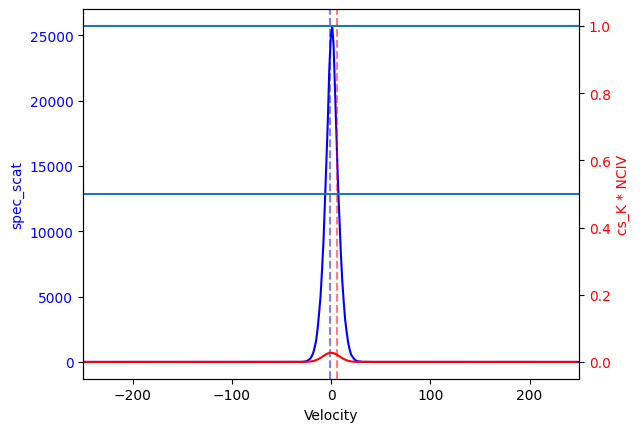

In [39]:
Line = 'K'
atom_num = 13
atom_index = 12
vout = 0
vemit = 1 
vran = 11.8
NCIV = (atom_num / 10)*10**atom_index
lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)


delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution_NCIV(Line, vran , NCIV)


nu_k = cc / (lam*1e-8)
Del_Vc = (CIV_nu_K/ nu_k -1)*cc_k

fig, ax1 = plt.subplots()

# 첫 번째 데이터 (왼쪽 y축)
ax1.plot(Del_Vc, spec_scat, color='blue')
ax1.set_xlabel('Velocity')
ax1.set_ylabel('spec_scat', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ii = np.argmax(spec_scat)
print(-Del_Vc[ii])
ax1.axvline(x=-Del_Vc[ii],ymin = 0, ymax= 1,linestyle='--',color='b',alpha=0.5)
# x 범위 통일
ax1.set_xlim(-250, 250)

# 두 번째 y축 생성
ax2 = ax1.twinx()

# 두 번째 데이터 (오른쪽 y축)
ax2.plot(delV_K, cs_K * NCIV  /np.sqrt(np.pi), color='red')
ax2.set_ylabel('cs_K * NCIV', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax2.axhline(y=1,xmin = 0, xmax= 1)
ax2.axhline(y=0.5,xmin = 0, xmax= 1)

nu_esc =(real_x_esc* CIV_nu_K)*(vran/cc_k) + CIV_nu_K
Vel_esc = (real_x_esc*vran)

ax2.axvline(x=5.9,ymin = 0, ymax= 1,linestyle = '--',color ='r',alpha=0.5)
print(Vel_esc)
plt.show()

(-250.0, 250.0)

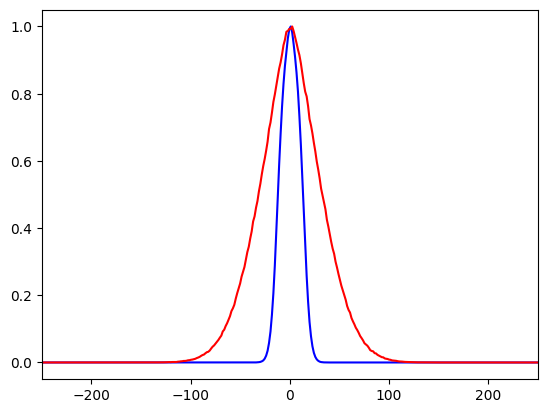

In [47]:
Line = 'K'
atom_num = 50
atom_index = 13
vout = 0
vemit = 1 
vran = 11.8
NCIV = (atom_num / 10)*10**atom_index
lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)


delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution_NCIV(Line, vran , NCIV)


nu_k = cc / (lam*1e-8)
Del_Vc = (CIV_nu_K/ nu_k -1)*cc_k


# 첫 번째 데이터 (왼쪽 y축)
plt.plot(Del_Vc, spec_scat/np.max(spec_scat), color='blue')

Line = 'K'
vran = 50
NCIV = (atom_num / 10)*10**atom_index
lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)

plt.plot(Del_Vc, spec_scat/np.max(spec_scat), color='red')


plt.xlim(-250, 250)

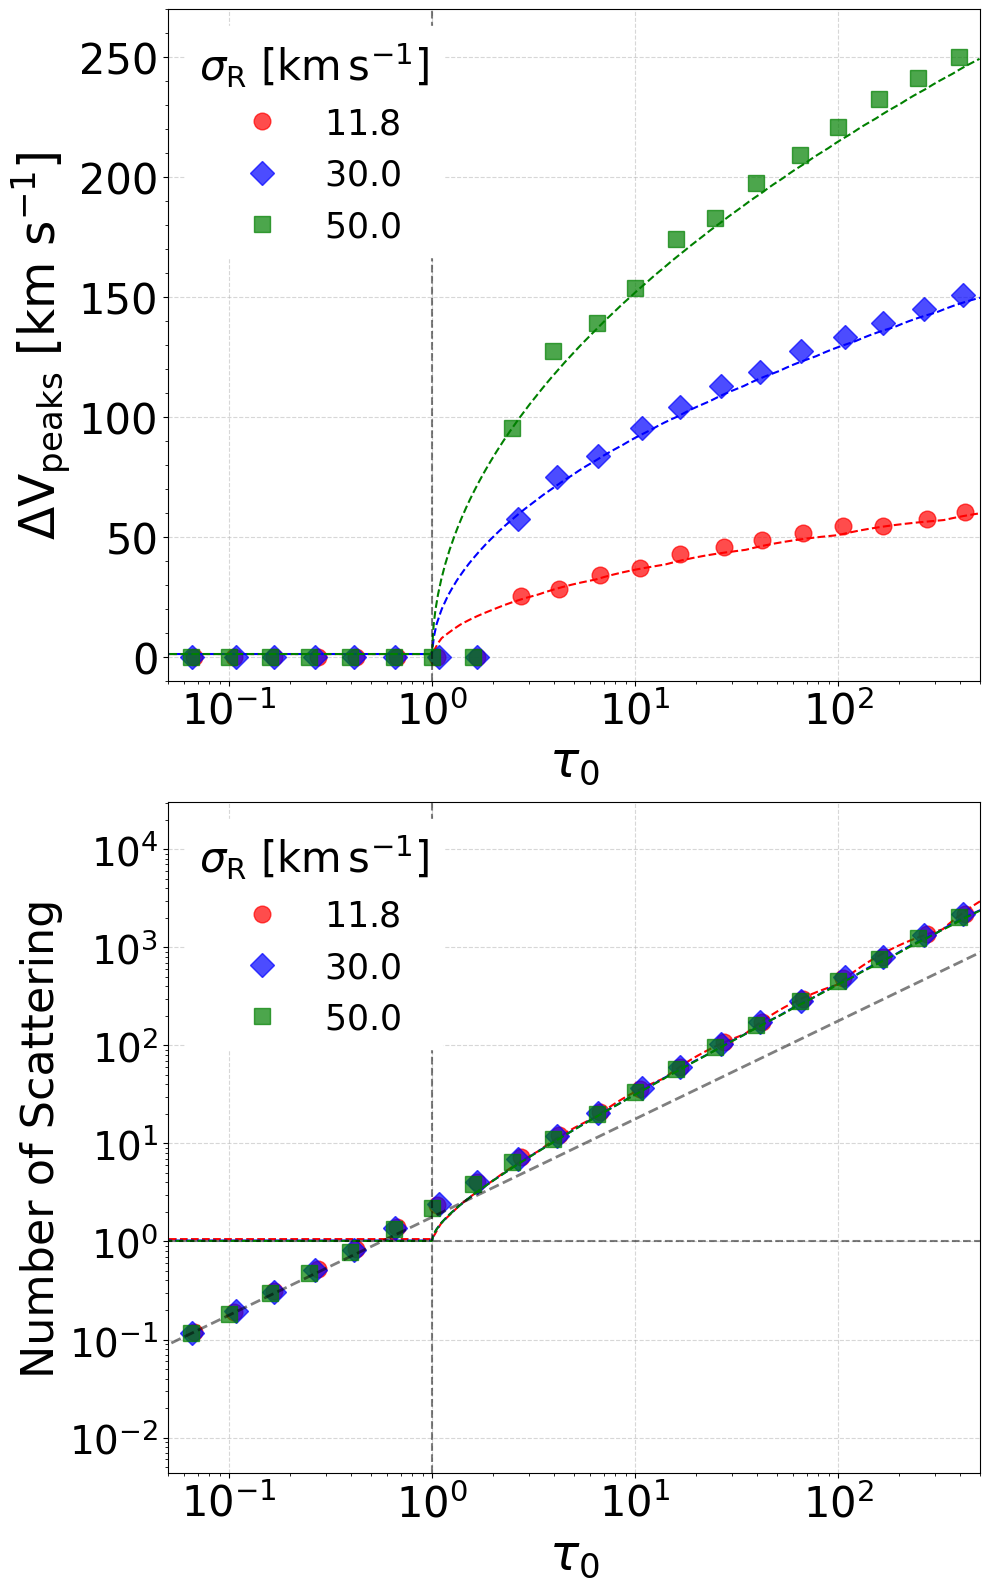

In [10]:
rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()



rand_nn = [11.8 , 30.0 , 50.0]
color = ['r','b','g']

fig = plt.figure(1,figsize=(10,16))

plt.subplot(211)

shape= np.array(['o','D','s'])

for kk , rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = []
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a , lam  = del_v_peaks('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)


    plt.plot(globals()[f"tau0_{name}"] , globals()[f"V_peak_sep_{name}"], linestyle='--',color=color[kk])
    plt.plot(tau, vv ,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))




plt.xlabel(r'$\tau_{\rm 0}$',fontsize=35)

plt.xscale('log')


plt.axvline(x=1,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)

plt.xlim(5e-2,5e2)
plt.ylim(-10,270)
plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =35)
plt.minorticks_on()
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
plt.tight_layout()


plt.subplot(212)
xx_thin = np.linspace(5e-3,5e3,1000)
xx_thick = np.linspace(1.0,5e3,1000)
tau_thin = xx_thin *np.sqrt(np.pi)


for kk , rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = []
    nos = []
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = data_scat('k',atom,index,0,1,rand)
            vv.append(a)

            

    plt.plot(globals()[f"tau0_{name}"], globals()[f"N_esc_{name}"], linestyle='--',color=color[kk])
    plt.plot(total_N_c*globals()[f"cross_sec_{name}"].max(), vv ,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))

    plt.xscale('log')

plt.plot(xx_thin,tau_thin,'k--',alpha=0.5,lw=2)

# tem = np.sqrt(np.log(xx_thin))
# tt = 1 / special.erfc(tem)

# plt.plot(xx_thin,tem,'r--')

plt.axvline(x=1,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)
plt.axhline(y=1,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)


# plt.axvline(x=320/2.67,ymin=0,ymax=1)
# plt.axhline(y=740,xmin=0,xmax=1)

plt.xlabel(r'$\tau_{\rm 0}$',fontsize=35)
plt.xscale('log')
plt.yscale('log')
# plt.xlim(2*10**12,3*10**16)
plt.xticks(fontsize=30)
plt.yticks(fontsize=28)
# plt.ylim(scat.min(),scat.max()+2)
plt.ylabel(r'Number of Scattering',fontsize =32)
plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
plt.xlim(5e-2,5e2)
plt.tight_layout()



# plt.savefig('/home/jin/바탕화면/simulation_vs_analyvic_jin_halo_mono.pdf',bbox_inches="tight")
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/simulation_vs_analyvic_jin_halo_mono.pdf',bbox_inches="tight")

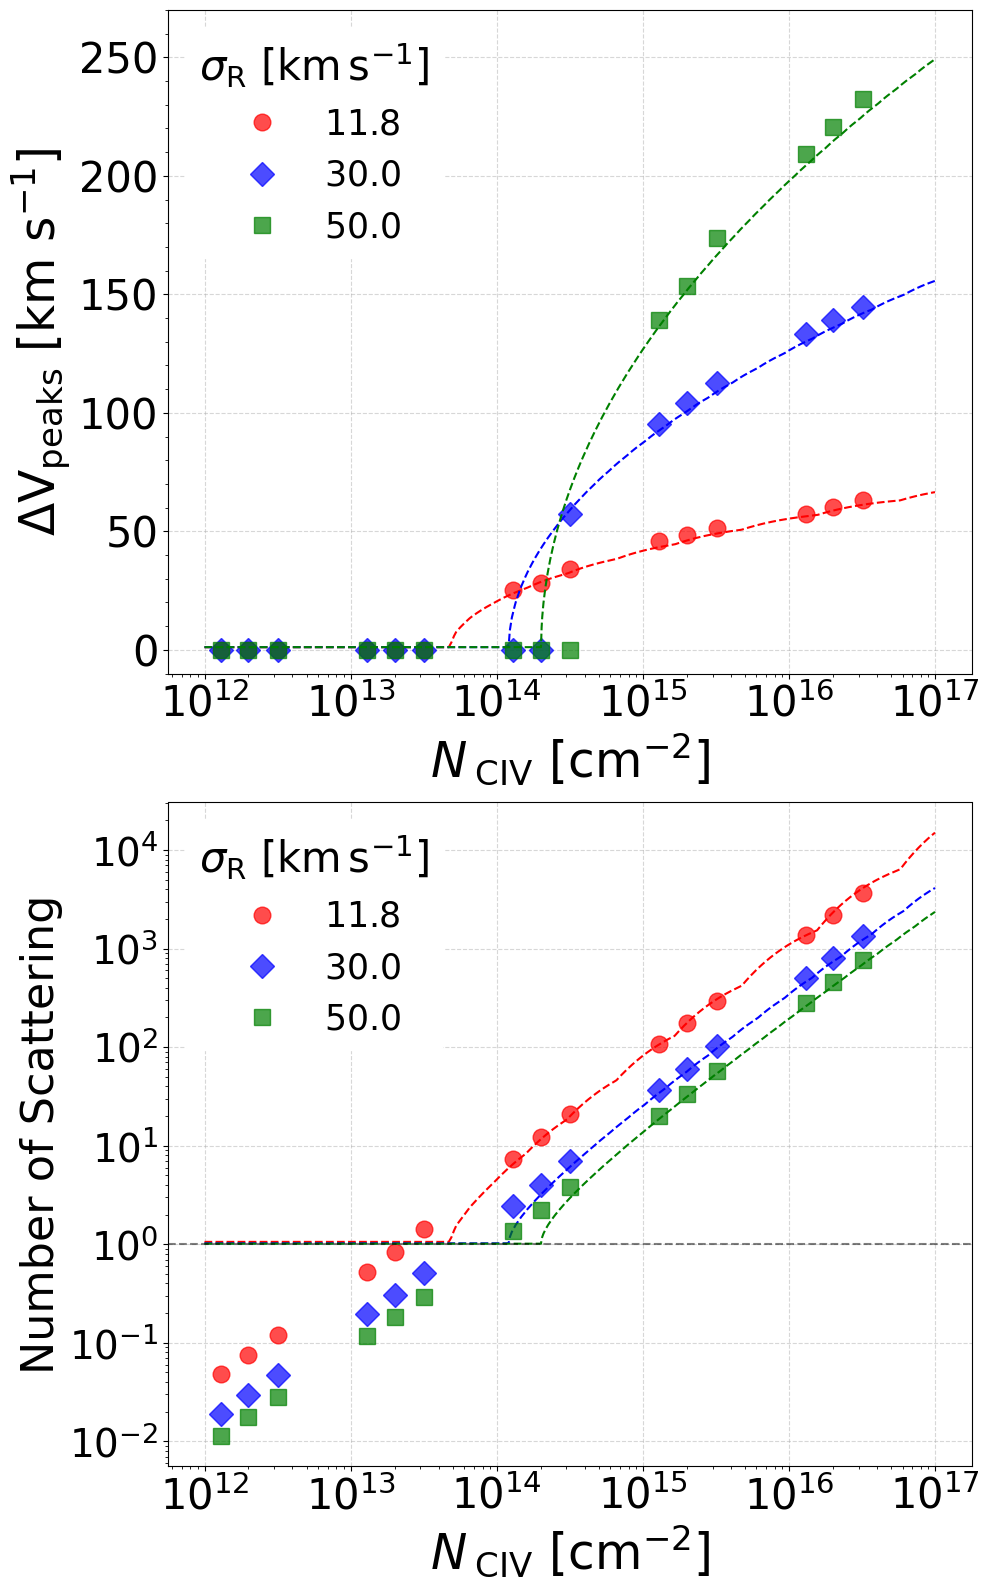

In [11]:
rr = np.arange(12, 17, 1)
atom_N = [13,20,32]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()



rand_nn = [11.8 , 30.0 , 50.0]
color = ['r','b','g']

fig = plt.figure(1,figsize=(10,16))

plt.subplot(211)

shape= np.array(['o','D','s'])

for kk , rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = []
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a , lam  = del_v_peaks('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)


    plt.plot(C_IV_N, globals()[f"V_peak_sep_{name}"], linestyle='--',color=color[kk])
    plt.plot(total_N_c, vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))




plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =35)


plt.xscale('log')


# plt.axvline(x=1,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)

# plt.xlim(5e-2,5e2)
plt.ylim(-10,270)
plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =35)
plt.minorticks_on()
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
plt.tight_layout()


plt.subplot(212)
xx_thin = np.linspace(5e-3,5e3,1000)
xx_thick = np.linspace(1.0,5e3,1000)
tau_thin = xx_thin



for kk , rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = []
    nos = []
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = data_scat('k',atom,index,0,1,rand)
            vv.append(a)

            

    plt.plot(C_IV_N, globals()[f"N_esc_{name}"], linestyle='--',color=color[kk])
    plt.plot(total_N_c , vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))

    plt.xscale('log')

# plt.plot(xx_thin,tau_thin,'k--',alpha=0.5,lw=2)



plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =35)

# plt.axvline(x=1,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)
plt.axhline(y=1,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)


plt.xscale('log')
plt.yscale('log')
# plt.xlim(2*10**12,3*10**16)
plt.xticks(fontsize=30)
plt.yticks(fontsize=28)
# plt.ylim(scat.min(),scat.max()+2)
plt.ylabel(r'Number of Scattering',fontsize =32)
plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
# plt.xlim(5e-2,5e2)
plt.tight_layout()



# plt.savefig('/home/jin/바탕화면/simulation_vs_analyvic_jin_halo_mono.pdf',bbox_inches="tight")
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/simulation_vs_analyvic_jin_halo_mono.pdf',bbox_inches="tight")

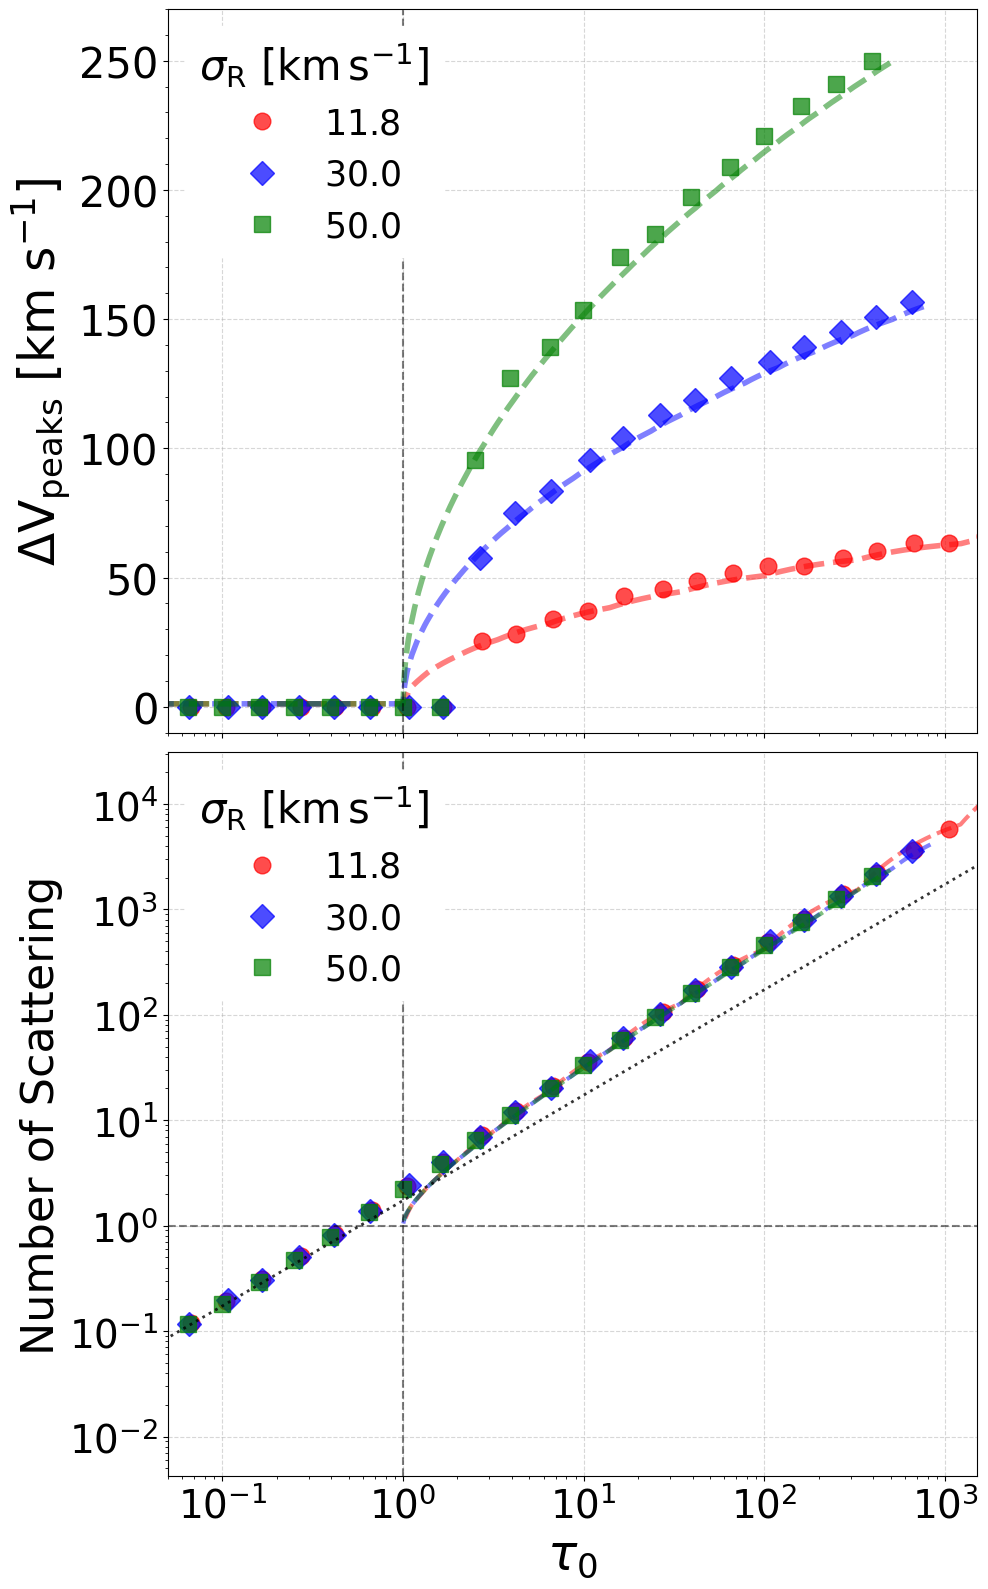

In [12]:
import numpy as np
import matplotlib.pyplot as plt

rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]

total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()

rand_nn = [11.8 , 30.0 , 50.0]
color = ['r','b','g']
shape= np.array(['o','D','s'])

# =========================

# Figure & shared x-axis

# =========================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,16), sharex=True)

# =========================

# TOP PANEL (Peak separation)

# =========================

for kk , rand in enumerate(rand_nn):

    name = str(rand).replace('.', '_')
    vv = []
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a , lam = del_v_peaks('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)



    ax1.plot(globals()[f"tau0_{name}"], globals()[f"V_peak_sep_{name}"],
            linestyle='--', alpha=0.5, color=color[kk], lw=4)

    ax1.plot(tau  , vv,
            marker=shape[kk], linestyle='', markersize=12,
            alpha=0.7, color=color[kk],
            label=r'${}$'.format(rand))


ax1.set_xscale('log')
ax1.set_ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]', fontsize=35)

ax1.axvline(x=1, linestyle='--', color='k', alpha=0.5)

ax1.set_ylim(-10,270)
ax1.tick_params(labelbottom=False)  # hide x tick labels

ax1.minorticks_on()
ax1.tick_params(axis='both', labelsize=30)
ax1.grid(True, linestyle='--', alpha=0.5)

leg1 = ax1.legend(
fontsize=25,
title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
loc='upper left',
title_fontsize=30,
frameon=True
)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(1)
leg1.get_frame().set_edgecolor('white')

# =========================

# BOTTOM PANEL (Number of scattering)

# =========================

xx_thin = np.linspace(5e-3,5e3,1000)
tau_thin = (xx_thin)

for kk , rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = []
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = data_scat('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)

    # if rand == 11.8:
        # xx_s = np.where(column_density * sig_c /(rand/11.8) > 0.9)[0]
    naa = np.where(globals()[f"tau0_{name}"] >= 1)
    ax2.plot(globals()[f"tau0_{name}"][naa], globals()[f"N_esc_{name}"][naa],
            linestyle='--', alpha=0.5, color = color[kk], lw=3)

    # if rand == 11.8 :
    #     nos = nos_tau_less_one(column_density,rand)
    #     ax2.plot(column_density* sig_c /(rand/11.8),nos,linestyle='--',alpha=0.5,color ='k',lw=2)

    ax2.plot(tau, vv,
            marker=shape[kk], linestyle='',
            markersize=12, alpha=0.7,
            color=color[kk],
            label=r'${}$'.format(rand))


# analytic thin line

ax2.plot(xx_thin, tau_thin*np.sqrt(3), 'k:', alpha=0.8, lw=2)

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.set_xlabel(r'$\tau_{\rm 0}$', fontsize=35)
ax2.set_ylabel(r'Number of Scattering', fontsize=32)

ax2.axvline(x=1, linestyle='--', color='k', alpha=0.5)
ax2.axhline(y=1, linestyle='--', color='k', alpha=0.5)

ax2.set_xlim(5e-2,1.5e3)

ax2.minorticks_on()
ax2.tick_params(axis='both', labelsize=28)
ax2.grid(True, linestyle='--', alpha=0.5)

leg2 = ax2.legend(
fontsize=25,
title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
loc='upper left',
title_fontsize=30,
frameon=True
)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(1)
leg2.get_frame().set_edgecolor('white')


from matplotlib.lines import Line2D

# 기존 legend (색 = sigma_R)
leg2 = ax2.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(1)
leg2.get_frame().set_edgecolor('white')

# =========================
# linestyle legend 추가
# =========================

# style_legend = [
#     Line2D([0], [0], color='k', linestyle=':', lw=3, label='Optically thin'),
#     Line2D([0], [0], color='k', linestyle='--', lw=3, label='Optically thick')
    
# ]

# leg_style = ax2.legend(
#     handles=style_legend,
#     fontsize=23,
#     title = r'$\langle N_{\rm scat} \rangle$',
#     title_fontsize=30,
#     loc='lower right',
#     frameon=True
# )
# leg_style.get_frame().set_facecolor('white')
# leg_style.get_frame().set_alpha(1)
# leg_style.get_frame().set_edgecolor('white')
# #   Line2D([0], [0], color='k', linestyle='', marker='o', markersize=10, label=r'$\langle N_{\rm scat} \rangle$')
# # 두 legend 동시에 유지
# ax2.add_artist(leg2)


# =========================

# spacing

# =========================

plt.subplots_adjust(hspace=0.05)
plt.tight_layout()

# plt.savefig('simulation_vs_analytic.pdf', bbox_inches="tight")

plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/simulation_vs_analyvic_jin_halo_mono.pdf',bbox_inches="tight")


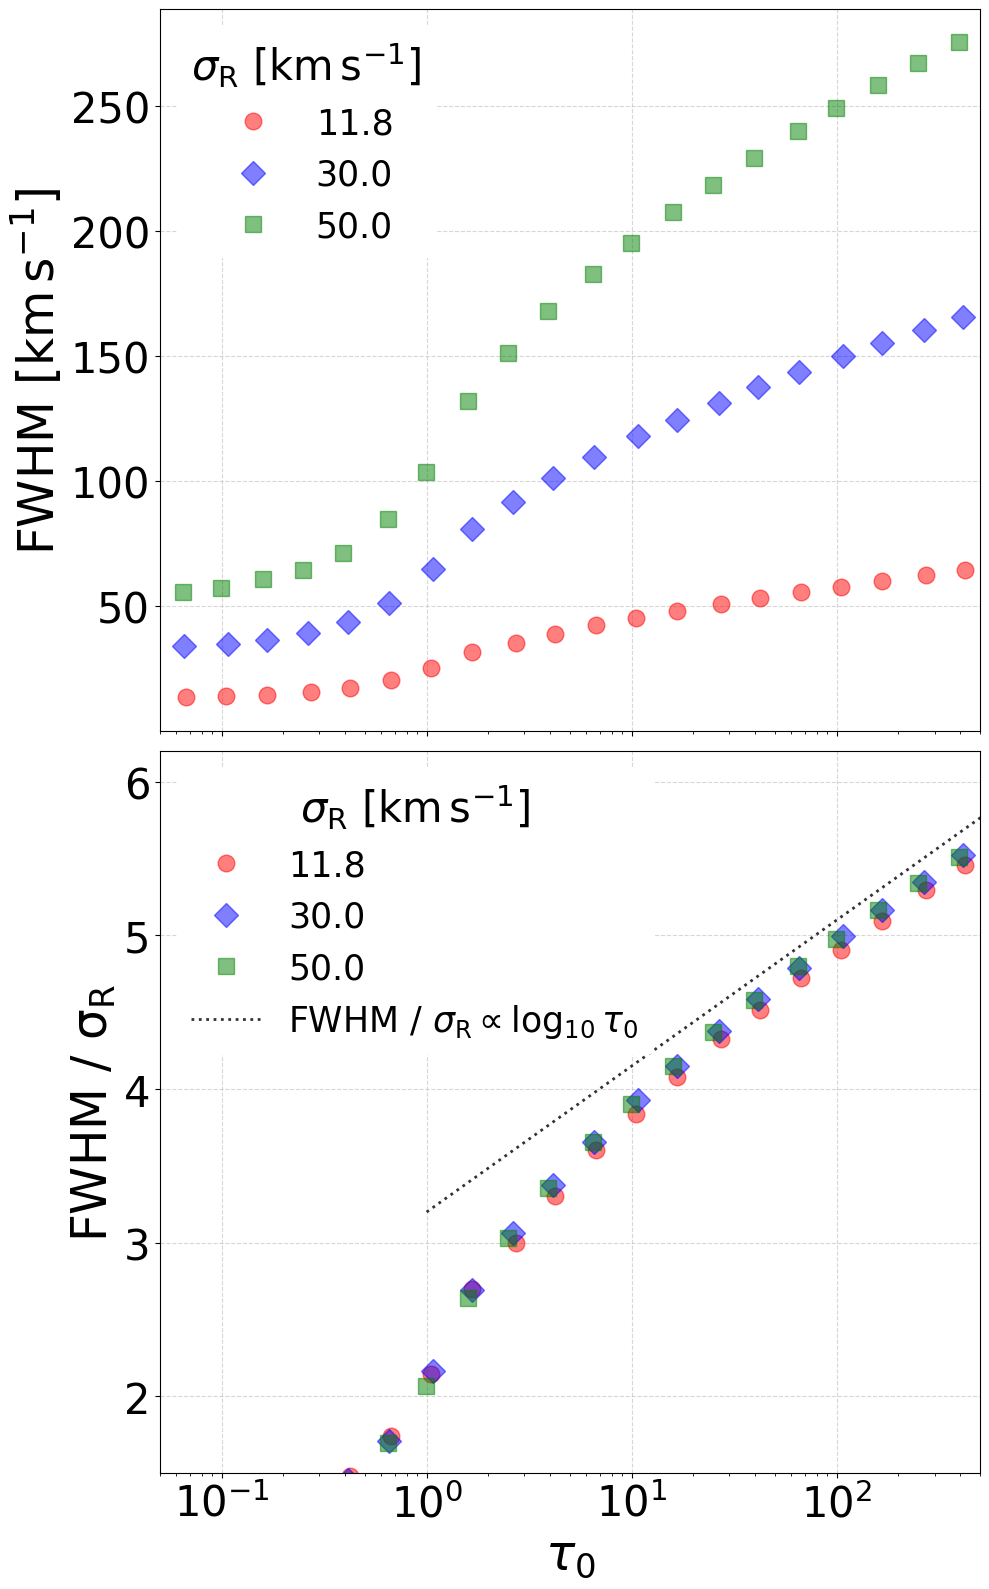

In [13]:
import numpy as np
import matplotlib.pyplot as plt

rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]

total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()

rand_nn = [11.8 , 30.0 , 50.0]
color = ['r','b','g']
shape = np.array(['o','D','s'])

# =========================

# shared x-axis figure

# =========================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,16), sharex=True)

# =========================

# TOP PANEL (FWHM)

# =========================

for kk , rand in enumerate(rand_nn):

    name = str(rand).replace('.', '_')
    vv = []
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)
    # vv = np.array(vv)
    # ax1.plot(globals()[f"tau0_{name}"], globals()[f"FWHM_{name}"],color=color[kk],linestyle='--')
    ax1.plot(tau, vv,
            marker=shape[kk], linestyle='None',
            markersize=12, color=color[kk],
            alpha=0.5, label=rf'{rand}')




ax1.set_xscale('log')
ax1.set_ylabel(r'$ \rm {FWHM} ~[\rm km \, s^{-1}]$', fontsize=35)

ax1.set_xlim(5e-2,5e2)
ax1.tick_params(labelbottom=False)  # hide top x-axis

ax1.tick_params(axis='both', labelsize=30)
ax1.grid(True, linestyle='--', alpha=0.5)

leg1 = ax1.legend(
fontsize=25,
title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
loc='upper left',
title_fontsize=30,
frameon=True
)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(1)
leg1.get_frame().set_edgecolor('white')

# =========================

# BOTTOM PANEL (FWHM / sigma_R)

# =========================

for kk , rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = np.array([])
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(vv,a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)

    # ax2.plot(globals()[f"tau0_{name}"], globals()[f"FWHM_{name}"]/rand, color=color[kk], linestyle='--')
    ax2.plot(tau, vv/rand,
             marker=shape[kk], linestyle='None',
             markersize=12, color=color[kk],
             alpha=0.5, label=rf'{rand}')


# scaling lines

# ax2.axhline(y=2.35/np.sqrt(2),xmin=0,xmax=1,color='k',linestyle='--')

xg = np.linspace(1.0, 1000.0, 2000)

yy_c = (0.95)*np.log10(xg) + 3.2
ax2.plot(xg, yy_c, linestyle=':', lw=2, color='k', alpha=0.8,
label=r'FWHM / $\sigma_{{\rm R}} \propto \log_{10}{\tau_0}$')

ax2.set_xscale('log')
ax2.set_xlabel(r'$\tau_{\rm 0}$', fontsize=35)
ax2.set_ylabel(r'$ \rm {FWHM} ~/~ {\sigma_R}$', fontsize=35)

ax2.set_xlim(5e-2,5e2)
ax2.set_ylim(1.5,6.2)

ax2.set_yticks([2,3,4,5,6])
ax2.tick_params(axis='both', labelsize=30)

ax2.grid(True, linestyle='--', alpha=0.5)

leg2 = ax2.legend(
fontsize=25,
title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
loc='upper left',
title_fontsize=30,
frameon=True
)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(1)
leg2.get_frame().set_edgecolor('white')
# =========================

# spacing

# =========================

plt.subplots_adjust(hspace=0.05)
plt.tight_layout()

plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/FWHM_ratio.pdf',bbox_inches="tight")
# plt.show()


/tmp/ipykernel_4528/3347882611.py:38: RuntimeWarning: Mean of empty slice
  y_med = np.nanmean(Y, axis=0)      # 3개 rand를 대표하는 곡선(중앙값 추천)


empirical: y = a log10(x) + b
a, b = 0.8921921332748218 3.1099842672395477


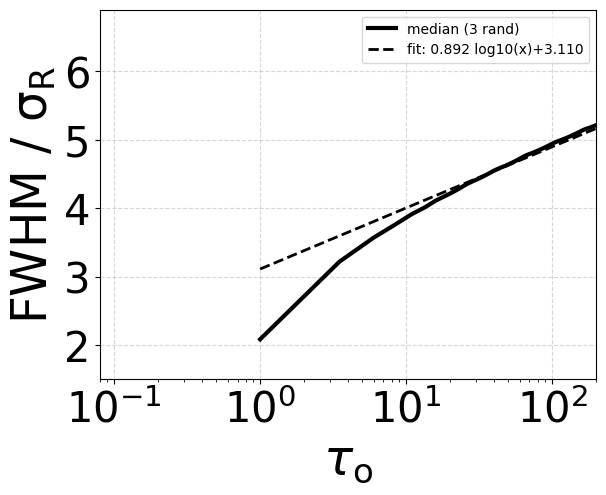

In [14]:
from scipy.optimize import curve_fit

def model_log10(x, a, b):
    return a*np.log10(x) + b

xg = np.linspace(1.0, 1e4, 4000)   # 공통 x-grid

Y = []  # 각 rand의 y(xg)를 모을 곳

for kk , rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = np.array([])
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(vv,a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)


    x = tau 
    y = vv / rand

    order = np.argsort(x)
    xs = x[order]
    ys = y[order]

    # x=1~100 구간만 “보간 가능한 범위”로 마스크 (외삽 방지)
    m = (xg >= xs.min()) & (xg <= xs.max())
    yg = np.full_like(xg, np.nan, dtype=float)
    yg[m] = np.interp(xg[m], xs, ys)

    Y.append(yg)

Y = np.array(Y)                      # shape: (3, len(xg))
y_med = np.nanmean(Y, axis=0)      # 3개 rand를 대표하는 곡선(중앙값 추천)

mask = np.isfinite(y_med)            # nan 제외
popt, pcov = curve_fit(model_log10, xg[mask], y_med[mask])
a_chi, b_chi = popt

print("empirical: y = a log10(x) + b")
print("a, b =", a_chi, b_chi)

plt.plot(xg, y_med, 'k', lw=3, label='median (3 rand)')
plt.plot(xg, model_log10(xg, a_chi, b_chi), 'k--', lw=2, label=rf'fit: {a_chi:.3f} log10(x)+{b_chi:.3f}')
plt.legend()


plt.xscale('log')
plt.xlabel(r'$\tau_{\rm o}$',fontsize=35)
plt.ylabel(r'$ \rm {FWHM} ~/~ {\sigma_R}$',fontsize=35)
plt.xlim(0.08,2e2)
plt.xticks(fontsize=30)
plt.yticks([2,3,4,5,6],fontsize=30)
plt.ylim(1.5,6.9)
plt.grid(True,linestyle='--',alpha=0.5)


In [15]:
def analytic_solution(Line, v_th):
 
    b = v_th
    sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

    del_nu_K = (b / cc_k) * CIV_nu_K
    del_nu_H = (b / cc_k) * CIV_nu_H

    x_K = (nu - CIV_nu_K) / del_nu_K
    x_H = (nu - CIV_nu_H) / del_nu_H

    a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
    a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

    K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
    H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)

    cross_sec = sigma0 * (K_term + H_term)

    K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
    H_region = np.where((Del_V >= Vsep - V_c) & (Del_V <= Vsep + V_c))

    delV_K, cs_K = Del_V[K_region], cross_sec[K_region]
    delV_H, cs_H = Del_V[H_region], cross_sec[H_region]

    x_kk = delV_K / (-b)
    x_hh = (delV_H - Vsep) / (-b)

    tau_profile_K = C_IV_N[:, None] * cs_K
    tau_profile_H = C_IV_N[:, None] * cs_H

    x_esc = np.zeros(len(C_IV_N))
    FWHM_tau05 = np.zeros(len(C_IV_N))

    def find_tau_crossings(x_arr, tau_arr, level):
        s = tau_arr - level
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_arr[jj], tau_arr[jj + 1]
            x_a, x_b = x_arr[jj], x_arr[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (level - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        return np.array(x_candidates)

    def get_width_with_your_rule(delv_arr, tau_arr):
        peak_ii = np.argmax(tau_arr)
        peak_tau = tau_arr[peak_ii]

        if peak_tau <= 1.0:
            level = 0.5 * peak_tau
        else:
            level = 0.5

        delV_half = find_tau_crossings(delv_arr, tau_arr, level)

        if len(delV_half) >= 2:
            return np.max(delV_half) - np.min(delV_half)

        elif len(delV_half) == 1:
            # 중심 대칭 fallback
            return 2.0 * np.abs(delV_half[0])

        else:
            # crossing이 하나도 없으면 peak 기준 대칭 fallback
            return 2.0 * np.abs(delv_arr[peak_ii])

    if Line.upper() == 'K':
        for ii in range(len(C_IV_N)):
            tau_i = tau_profile_K[ii, :]

            # tau = 1 crossing
            x_tau1 = find_tau_crossings(x_kk, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc[ii] = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i)
                x_esc[ii] = np.abs(x_kk[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05[ii] = get_width_with_your_rule(delV_K, tau_i)

        del_lam_D = (b * 1e5) / C_IV_K
        nu_0_K = cc / C_IV_K
        real_x_esc = 2*x_esc 
        nu_esc = real_x_esc * del_lam_D + nu_0_K
        V_peak_sep = 2 * abs((nu_esc - nu_0_K) / nu_0_K) * cc / 1e5
        v_esc = x_esc * b
        N_esc = 1 / special.erfc(real_x_esc)

        return delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05
    
delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution('k', 11.8)

print(V_peak_sep, FWHM_tau05)

[  2.25500065   2.25500065   2.25500065 ... 137.23982161 137.23992895
 137.24003628] [19.73561315 19.73561315 19.73561315 ... 72.11856646 72.11865415
 72.11874183]


12.845058821683002
2.4660603553e+15
2.4660713244e+15
5.890598e-14


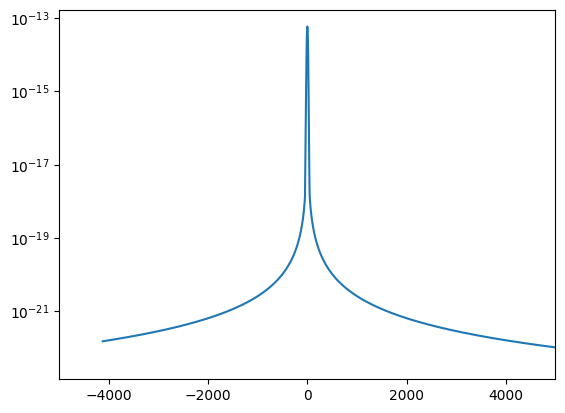

In [16]:
e = 1.602e-19*3e9
m_u = 1.66054e-24
m_e = 9.10938356e-28
m_H = 1.6737236e-24

c = 2.99792458e10 


H_I_gamma_H = 6.2649e+8
H_I_gamma_K = 6.2648e+8
H_I_f12_H   = 0.13881
H_I_f12_K   = 0.2776
H_I_f12     = H_I_f12_H + H_I_f12_K 
H_I_wlH     = 1215.673644608e-8
H_I_wlK     = 1215.668237310e-8
H_I_nuH     = c/H_I_wlH
H_I_nuK     = c/H_I_wlK
H_I_nu_0    = (H_I_nuH + 2.e0*H_I_nuK)/3.e0
H_I_wlc_0   = c/H_I_nu_0*1e8
H_I_sigma_0 = H_I_f12*np.sqrt(np.pi)*e**2/(m_e*c) 
H_I_mass    = 1.00784*m_u

T = 1.e4
kb= 1.38064852e-16
sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)
v_th = np.sqrt(2*kb*T/H_I_mass)
print(v_th/1e5)

print(f"{H_I_nuH:.10e}")
print(f"{H_I_nuK:.10e}")


nu = np.arange(2.4e+15, 2.5e+15,0.000001e15)


del_nu_K = (v_th / c) * H_I_nuK 
del_nu_H = (v_th / c) * H_I_nuH 

# print(H_I_nuK)
x_K = (nu -  H_I_nuK) / del_nu_K
x_H = (nu -  H_I_nuH) / del_nu_H

a_K = H_I_gamma_K / (4 * np.pi * del_nu_K)
a_H = H_I_gamma_H  / (4 * np.pi * del_nu_H)

K_term = (H_I_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
H_term = (H_I_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)

cross_sec = sigma0 * (K_term + H_term)

Del_V = (-x_K * v_th)/1e5


plt.plot(Del_V,cross_sec)
# plt.xscale('log')
plt.yscale('log')
plt.xlim(-5000,5000)
print(f"{cross_sec.max():2e}")
# # plt.xlim( H_I_nuH - 0.05,  H_I_nuK+0.05)

In [17]:
T = 1.05e4
vv_lya = 12.85*(T/1e4)**0.5 # Lya
print(vv_lya)

vv_mgii = 8.27*(T/1e5)**0.5 # Lya
print(vv_mgii)


13.167331734258084
2.6797862787916498


15.0
1.0696539878e+15
1.0724001262e+15
1.697922e-13
5.889554e+12


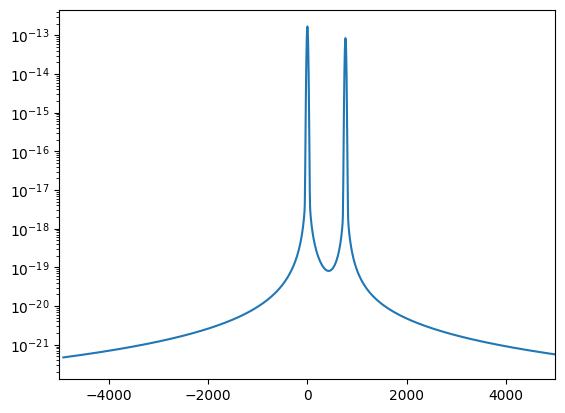

In [18]:
H_I_gamma_H = 6.2649e+8
H_I_gamma_K = 6.2648e+8
H_I_f12_H   = 0.13881
H_I_f12_K   = 0.2776
H_I_f12     = H_I_f12_H + H_I_f12_K 
H_I_wlH     = 1215.673644608e-8
H_I_wlK     = 1215.668237310e-8
H_I_nuH     = c/H_I_wlH
H_I_nuK     = c/H_I_wlK
H_I_nu_0    = (H_I_nuH + 2.e0*H_I_nuK)/3.e0
H_I_wlc_0   = c/H_I_nu_0*1e8
H_I_sigma_0 = H_I_f12*np.sqrt(np.pi)*e**2/(m_e*c) 
H_I_mass    = 1.00784*m_u



Mg_II_gamma_H = 2.57e+8 
Mg_II_gamma_K = 2.60e+8 
Mg_II_f12_H   = 0.303e0 
Mg_II_f12_K   = 0.608e0 
Mg_II_f12     = Mg_II_f12_H + Mg_II_f12_K 
Mg_II_wlH     = 2802.705e-8
Mg_II_wlK     = 2795.528e-8 
Mg_II_nuH     = c/Mg_II_wlH
Mg_II_nuK     = c/Mg_II_wlK
Mg_II_nu_0    = (Mg_II_f12_H*Mg_II_nuH + Mg_II_f12_K*Mg_II_nuK)/Mg_II_f12
Mg_II_wlc_0   = c/Mg_II_nu_0*1e8
Mg_II_sigma_0 = Mg_II_f12*np.sqrt(np.pi)*e**2/(m_e*c) 
Mg_II_mass    = 24.305e0*m_u - m_e

T = 1e4
kb= 1.38064852e-16
sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)
# v_th = np.sqrt(2*kb*T/Mg_II_mass)
v_th = 15e5
print(v_th/1e5)

print(f"{Mg_II_nuH:.10e}")
print(f"{Mg_II_nuK:.10e}")


nu = np.arange(1.05e+15, 1.09e+15,0.000001e15)


del_nu_K = (v_th / c) * Mg_II_nuK 
del_nu_H = (v_th / c) * Mg_II_nuH 

# print(H_I_nuK)
x_K = (nu -  Mg_II_nuK) / del_nu_K
x_H = (nu -  Mg_II_nuH) / del_nu_H

a_K = Mg_II_gamma_K / (4 * np.pi * del_nu_K)
a_H = Mg_II_gamma_H  / (4 * np.pi * del_nu_H)

K_term = (Mg_II_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
H_term = (Mg_II_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)

cross_sec = sigma0 * (K_term + H_term)

Del_V = (-x_K * v_th)/1e5

plt.plot(Del_V,cross_sec)
# plt.xscale('log')
plt.yscale('log')
plt.xlim(-5000,5000)
print(f"{cross_sec.max():2e}")
print(f"{1/cross_sec.max():2e}")


In [19]:
T = 1e4
sigma_Lya = 5.9e-14*(T/1e4)**(-0.5)

NCIV = 1.029320e+12 
f_civ =  0.190e0
f_mgii = 0.608e0 
T = 1e4
M = 24

sigma =  (f_mgii / 0.4164)* (M)**(0.5)  * sigma_Lya   # * (Mg_II_wlK/H_I_wlK) # Weight
print(f"{1/sigma:2e}")

2.369461e+12


In [20]:
T = 1e4
kb= 1.38064852e-16
sigma0 = (np.sqrt(np.pi) * e**2) / (m_e * cc)
v_th = np.sqrt(2*kb*T/Mg_II_mass)
print(v_th/1e5)

2.615706318033715


In [21]:
T = 1e5
sigma_Lya = 5.9e-14*(T/1e4)**(-0.5)

NCIV = 2.67e13
f_c =  0.190e0
T = 1e5
M = 12

tau =  (f_c / 0.4164)* (M)**(0.5)  * sigma_Lya * (NCIV)  * (C_IV_K/H_I_wlK)

print(tau)

1.002778751485236


In [22]:
nu = np.arange(2.466058e+15, 2.466072e+15,0.00001e15)